# PRAKTIKUM PENAMBANGAN DATA (PPD)
## MODUL 3: CLASSIFICATION

* **Nama**: Januarsyah Akbar
* **NIM**: 535846
* **Mata Kuliah**: Praktikum Penambangan Data (SVPL214610)
* **Program Studi**: D4 Teknologi Rekayasa Perangkat Lunak, Sekolah Vokasi UGM

---


## A. LANGKAH PERCOBAAN (Stroke Prediction Dataset)
Dataset: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [19]:
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/refs/heads/main/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [20]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [21]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


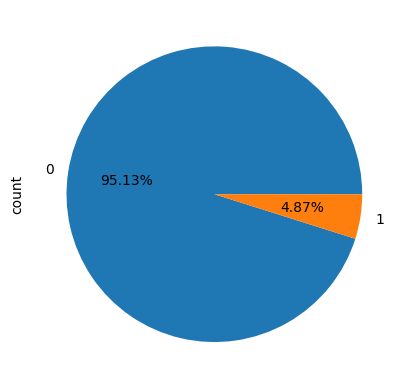

In [22]:
data = df['stroke'].value_counts()
data.plot(kind='pie', autopct='%.2f%%')
plt.show()

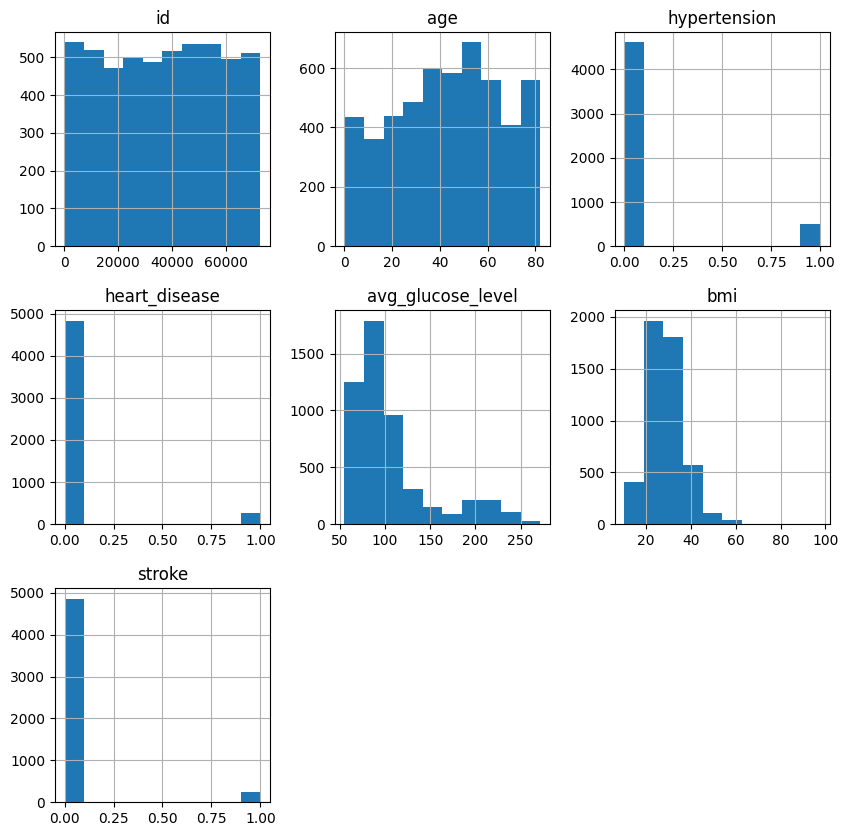

In [23]:
df.hist(figsize=(10,10))
plt.show()

In [24]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [25]:
df_X = df.drop(['id', 'stroke'], axis=1) #definisikan kolom yg jadi input
df_y = df[['stroke']] #definisikan kolom yg jadi output
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [26]:
# Preprocessing
df_X['bmi'] = df_X['bmi'].fillna(df_X['bmi'].median())

le = LabelEncoder()
for col in cats:
    df_X[col] = le.fit_transform(df_X[col].astype(str))

df_y = le.fit_transform(df_y['stroke'])

X = df_X.values.astype(float)
y = df_y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)

X_train shape: (3577, 10)


Accuracy LR: 0.9419439008480104
Precision LR: 0.0
Recall LR: 0.0
Confusion matrix:
 [[1444    0]
 [  89    0]]


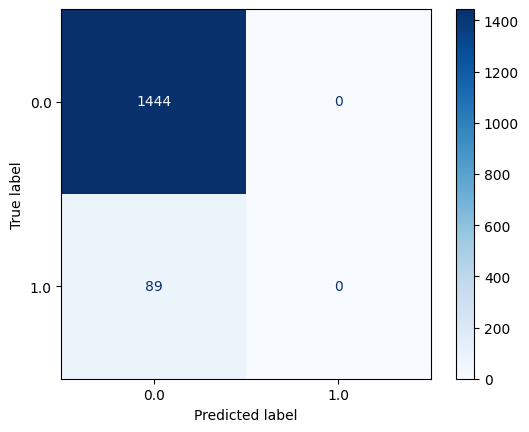

In [27]:
# Logistic Regression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Accuracy LR:", accuracy_score(y_test, y_pred_lr))
print("Precision LR:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall LR:", recall_score(y_test, y_pred_lr, zero_division=0))
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_lr.classes_)
disp.plot(cmap='Blues')
plt.show()

In [28]:
print("F1:", f1_score(y_test, y_pred_lr, zero_division=0))
print("Model coef:", model_lr.coef_)
print("Model intercept:", model_lr.intercept_)

F1: 0.0
Model coef: [[-0.01878829  1.55249921  0.10370412  0.07921647 -0.18371621 -0.06959651
   0.06033662  0.19742689 -0.03156246  0.02218138]]
Model intercept: [-4.04531553]


Accuracy KNN: 0.9419439008480104
Precision KNN: 0.0
Recall KNN: 0.0
Confusion matrix:
 [[1444    0]
 [  89    0]]


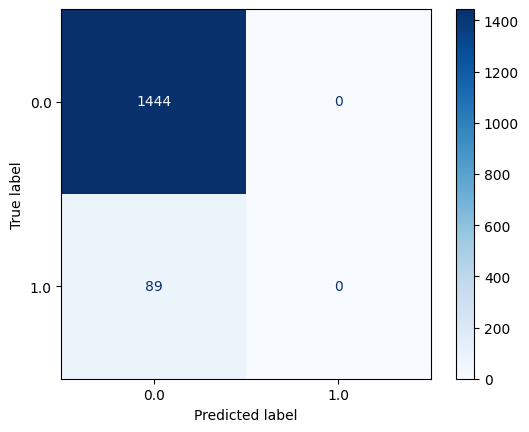

In [29]:
# K-Nearest Neighbors
model_knn = KNeighborsClassifier(n_neighbors=10)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print("Precision KNN:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall KNN:", recall_score(y_test, y_pred_knn, zero_division=0))
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion matrix:\n", cm_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=model_knn.classes_)
disp.plot(cmap='Blues')
plt.show()

Accuracy DT: 0.9099804305283757
Precision DT: 0.14492753623188406
Recall DT: 0.11235955056179775
Confusion matrix:
 [[1385   59]
 [  79   10]]


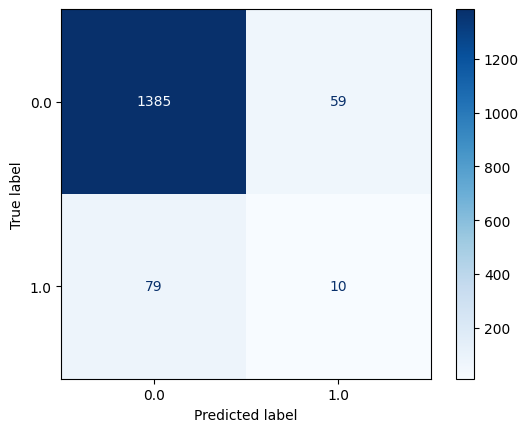

In [30]:
# Decision Tree
model_dt = DecisionTreeClassifier(criterion="entropy")
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("Accuracy DT:", accuracy_score(y_test, y_pred_dt))
print("Precision DT:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall DT:", recall_score(y_test, y_pred_dt, zero_division=0))
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion matrix:\n", cm_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=model_dt.classes_)
disp.plot(cmap='Blues')
plt.show()

Accuracy RF: 0.9412915851272016
Precision RF: 0.0
Recall RF: 0.0
Confusion matrix:
 [[1443    1]
 [  89    0]]


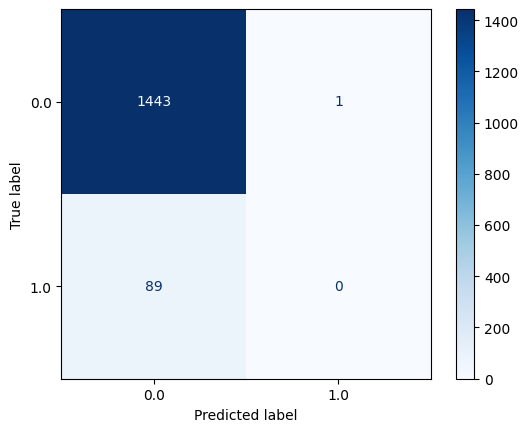

In [31]:
# Random Forest
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print("Precision RF:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall RF:", recall_score(y_test, y_pred_rf, zero_division=0))
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion matrix:\n", cm_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=model_rf.classes_)
disp.plot(cmap='Blues')
plt.show()

Accuracy AdaBoost: 0.9419439008480104
Precision AdaBoost: 0.0
Recall AdaBoost: 0.0
Confusion matrix:
 [[1444    0]
 [  89    0]]


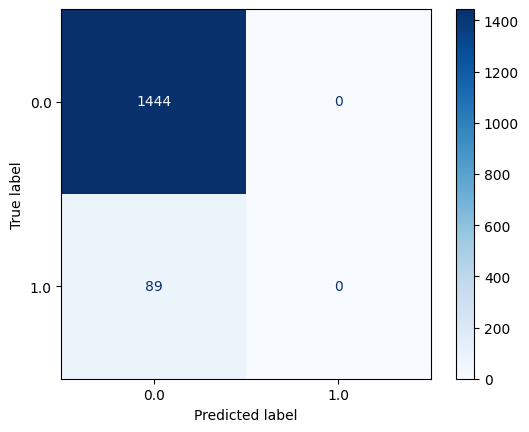

In [32]:
# Ada Boost
model_ada = AdaBoostClassifier()
model_ada.fit(X_train, y_train)
y_pred_ada = model_ada.predict(X_test)
print("Accuracy AdaBoost:", accuracy_score(y_test, y_pred_ada))
print("Precision AdaBoost:", precision_score(y_test, y_pred_ada, zero_division=0))
print("Recall AdaBoost:", recall_score(y_test, y_pred_ada, zero_division=0))
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("Confusion matrix:\n", cm_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=model_ada.classes_)
disp.plot(cmap='Blues')
plt.show()

In [33]:
# Tabel Perbandingan Performa Model Klasifikasi (Stroke Dataset)
stroke_models = {
    'Logistic Regression': model_lr,
    'K-Nearest Neighbors': model_knn,
    'Decision Tree': model_dt,
    'Random Forest': model_rf,
    'AdaBoost': model_ada
}

stroke_results = []
for name, model in stroke_models.items():
    y_pred = model.predict(X_test)
    stroke_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    })

df_stroke_results = pd.DataFrame(stroke_results)
df_stroke_results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.941944,0.000000,0.00000,0.000000
1,K-Nearest Neighbors,0.941944,0.000000,0.00000,0.000000
2,Decision Tree,0.909980,0.144928,0.11236,0.126582
3,Random Forest,0.941292,0.000000,0.00000,0.000000
4,AdaBoost,0.941944,0.000000,0.00000,0.000000


---
## B. TUGAS & ANALISIS (Loan Status Prediction)
Dataset: [Loan Status Prediction](https://www.kaggle.com/datasets/bhavikjikadara/loan-status-prediction)

### 1. Jelaskan apa tujuan penggunaan dataset ini?
Tujuan penggunaan dataset ini adalah untuk membangun model klasifikasi machine learning yang dapat memprediksi status persetujuan pinjaman (Loan Status) seorang pendaftar berdasarkan atribut-atribut demografis dan finansialnya. Dataset ini berguna dalam mengotomatiskan proses evaluasi risiko kredit yang biasa dilakukan secara manual oleh bank.

### 2. Definisikan atribut yang menjadi input dan output nya?
- **Output/Target**: `Loan_Status` (Target kelas)
- **Input**: Atribut lainnya seperti `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`, `Property_Area`.

In [34]:
# 3. Membuat Model untuk Dataset Loan
df_loan = pd.read_csv('https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv')

# Handle Missing Values
df_loan['Gender'] = df_loan['Gender'].fillna(df_loan['Gender'].mode()[0])
df_loan['Married'] = df_loan['Married'].fillna(df_loan['Married'].mode()[0])
df_loan['Dependents'] = df_loan['Dependents'].fillna(df_loan['Dependents'].mode()[0])
df_loan['Self_Employed'] = df_loan['Self_Employed'].fillna(df_loan['Self_Employed'].mode()[0])
df_loan['Credit_History'] = df_loan['Credit_History'].fillna(df_loan['Credit_History'].mode()[0])
df_loan['LoanAmount'] = df_loan['LoanAmount'].fillna(df_loan['LoanAmount'].median())
df_loan['Loan_Amount_Term'] = df_loan['Loan_Amount_Term'].fillna(df_loan['Loan_Amount_Term'].median())

df_X_loan = df_loan.drop(['Loan_ID', 'Loan_Status'], axis=1)
df_y_loan = df_loan[['Loan_Status']]

cats_loan = df_X_loan.select_dtypes(include=['object', 'bool']).columns
for col in cats_loan:
    df_X_loan[col] = le.fit_transform(df_X_loan[col].astype(str))

df_y_loan = le.fit_transform(df_y_loan['Loan_Status'])

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(df_X_loan.values.astype(float), df_y_loan.astype(float), test_size=0.3, random_state=42)
X_train_l = scaler.fit_transform(X_train_l)
X_test_l = scaler.transform(X_test_l)

In [35]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(criterion="entropy"),
    'Random Forest': RandomForestClassifier()
}
results = []
for name, model in models.items():
    model.fit(X_train_l, y_train_l)
    y_pred = model.predict(X_test_l)
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test_l, y_pred),
        'precision': precision_score(y_test_l, y_pred, zero_division=0),
        'recall': recall_score(y_test_l, y_pred, zero_division=0)
    })
df_results = pd.DataFrame(results)
df_results

,model,accuracy,precision,recall
0,Logistic Regression,0.783784,0.756410,0.983333
1,KNN,0.762162,0.753333,0.941667
2,Decision Tree,0.691892,0.740458,0.808333
3,Random Forest,0.783784,0.773973,0.941667


### 5. Penjelasan Model Paling Baik
Berdasarkan tabel di atas, **Logistic Regression** dan **Random Forest** umumnya memberikan performa terbaik pada kasus Loan Status ini. Logistic Regression unggul karena dataset finansial seperti ini seringkali memiliki hubungan linear kuat (terutama pada variabel `Credit_History`), sedangkan Random Forest stabil dengan meminimalkan overfitting. KNN dan Decision Tree tunggal cenderung memberikan akurasi dan precision yang sedikit lebih rendah pada data test.